In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
try:
    df = pd.read_csv("kidney_disease.csv")
    
except FileNotFoundError:
    print("File not found")
except Exception as e:
    print(str(e))

else:
    print("Loaded...")

Loaded...


In [4]:
df.head()
df.shape

(400, 26)

In [5]:
df.describe()

,Id,Age,Blood Pressure,SG,Albumin,Sugar,Random Glucose,Blood Urea,Creatinine,Sodium,Potassium,Haemoglobin
count,400.000000,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000
mean,199.500000,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437
std,115.614301,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587
min,0.000000,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000
25%,99.750000,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000
50%,199.500000,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000
75%,299.250000,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000
max,399.000000,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000


In [6]:
df.dtypes

Id                  int64
Age               float64
Blood Pressure    float64
SG                float64
Albumin           float64
Sugar             float64
RBC                   str
Pus Cell              str
PC Clumps             str
Bacteria              str
Random Glucose    float64
Blood Urea        float64
Creatinine        float64
Sodium            float64
Potassium         float64
Haemoglobin       float64
PCV                   str
WBC Count             str
RBC Count             str
Hypertension          str
Diabetes              str
Artery disease        str
Appetite              str
Petal Edema           str
Anaemia               str
Classification        str
dtype: object

In [7]:
df["Classification"].value_counts(normalize=True)

Classification
ckd       0.620
notckd    0.375
ckd\t     0.005
Name: proportion, dtype: float64

C:\Users\USER\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


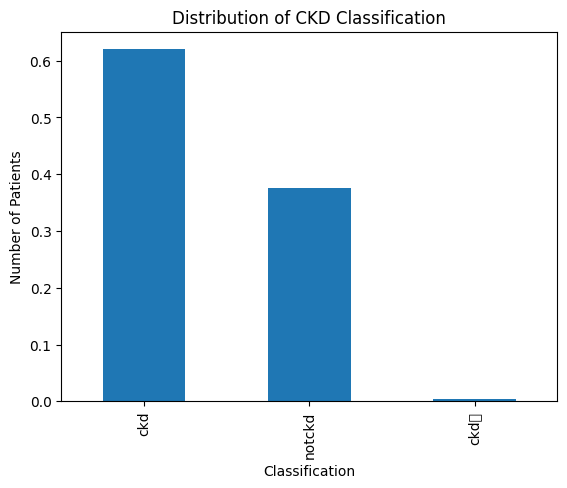

In [8]:
df["Classification"].value_counts(normalize=True).plot(kind='bar')
plt.title("Distribution of CKD Classification")
plt.xlabel("Classification")
plt.ylabel("Number of Patients")
plt.show()


In [9]:
#Missing Values Investigation
missing = df.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))


RBC               152
RBC Count         130
WBC Count         105
Potassium          88
Sodium             87
PCV                70
Pus Cell           65
Haemoglobin        52
Sugar              49
SG                 47
Albumin            46
Random Glucose     44
Blood Urea         19
Creatinine         17
Blood Pressure     12
Age                 9
PC Clumps           4
Bacteria            4
Hypertension        2
Diabetes            2
Artery disease      2
Appetite            1
Petal Edema         1
Anaemia             1
dtype: int64


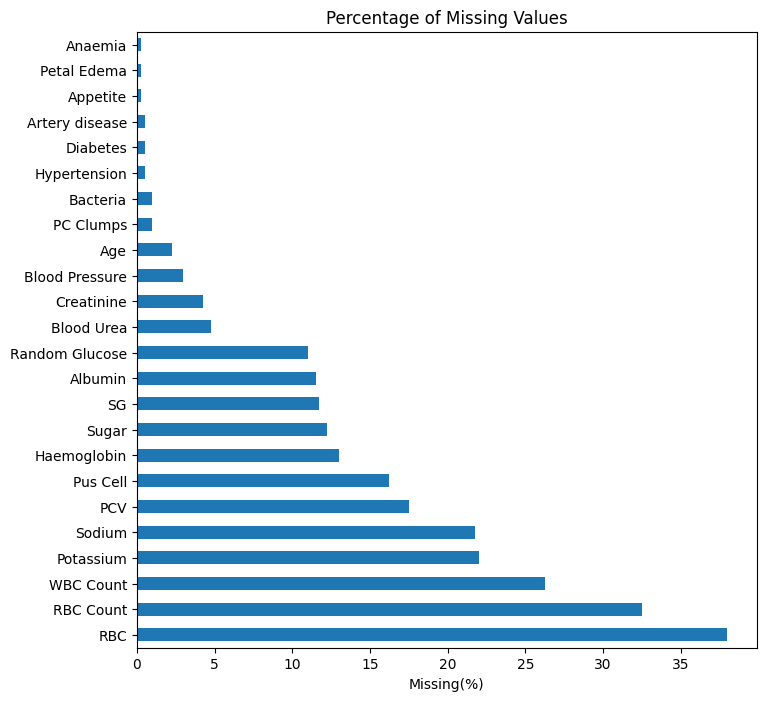

In [10]:
missing_pct = df.isnull().mean() * 100
missing_pct[missing_pct > 0].sort_values(ascending=False)

missing_table = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
})

missing_pct[missing_pct > 0].sort_values(ascending=False).plot(kind="barh", figsize = (8, 8))
plt.title("Percentage of Missing Values")
plt.xlabel("Missing(%)")
plt.show()

In [11]:
target = (df["Classification"].astype(str).str.strip())
print(target.value_counts(normalize=True))

missing_by_target = {}

for col in df.columns:
    if df[col].isnull().sum() > 0:
        missing_by_target[col] = pd.crosstab(
            df[col].isnull(),
            target,
            normalize="columns"
            
        ) * 100
print(missing_by_target)

Classification
ckd       0.625
notckd    0.375
Name: proportion, dtype: float64
{'Age': Classification   ckd     notckd
Age                            
False           96.8  99.333333
True             3.2   0.666667, 'Blood Pressure': Classification   ckd     notckd
Blood Pressure                 
False           96.0  98.666667
True             4.0   1.333333, 'SG': Classification   ckd     notckd
SG                             
False           83.2  96.666667
True            16.8   3.333333, 'Albumin': Classification   ckd     notckd
Albumin                        
False           83.6  96.666667
True            16.4   3.333333, 'Sugar': Classification   ckd     notckd
Sugar                          
False           82.4  96.666667
True            17.6   3.333333, 'RBC': Classification   ckd  notckd
RBC                         
False           42.8    94.0
True            57.2     6.0, 'Pus Cell': Classification   ckd  notckd
Pus Cell                    
False           77.6    94.0


In [12]:
numeric_cols = df.select_dtypes(include="number").columns
numeric_cols

Index(['Id', 'Age', 'Blood Pressure', 'SG', 'Albumin', 'Sugar',
       'Random Glucose', 'Blood Urea', 'Creatinine', 'Sodium', 'Potassium',
       'Haemoglobin'],
      dtype='str')

In [13]:
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Id,400.0,199.500000,115.614301,0.000,99.75,199.50,299.25,399.000
Age,391.0,51.483376,17.169714,2.000,42.00,55.00,64.50,90.000
Blood Pressure,388.0,76.469072,13.683637,50.000,70.00,80.00,80.00,180.000
SG,353.0,1.017408,0.005717,1.005,1.01,1.02,1.02,1.025
Albumin,354.0,1.016949,1.352679,0.000,0.00,0.00,2.00,5.000
Sugar,351.0,0.450142,1.099191,0.000,0.00,0.00,0.00,5.000
Random Glucose,356.0,148.036517,79.281714,22.000,99.00,121.00,163.00,490.000
Blood Urea,381.0,57.425722,50.503006,1.500,27.00,42.00,66.00,391.000
Creatinine,383.0,3.072454,5.741126,0.400,0.90,1.30,2.80,76.000
Sodium,313.0,137.528754,10.408752,4.500,135.00,138.00,142.00,163.000


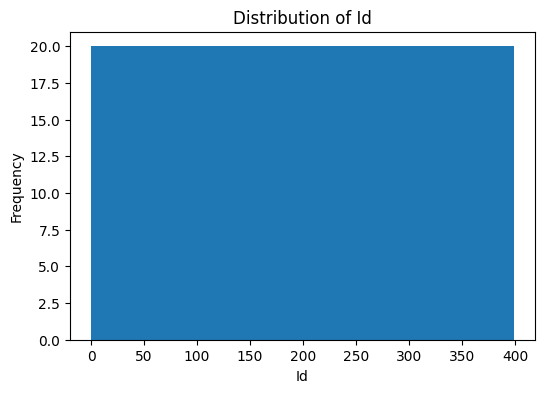

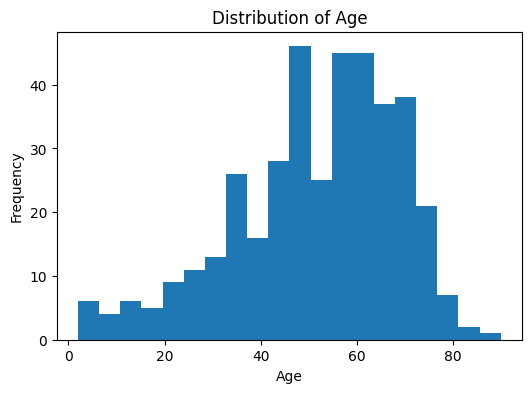

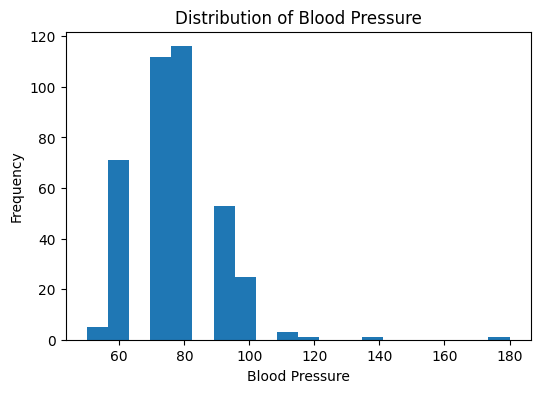

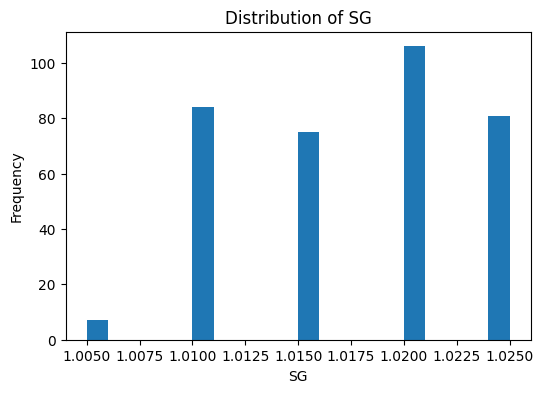

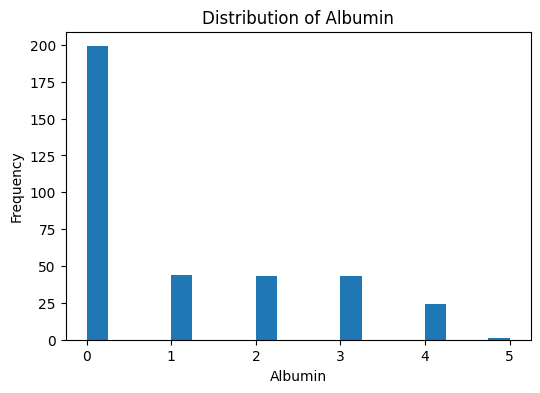

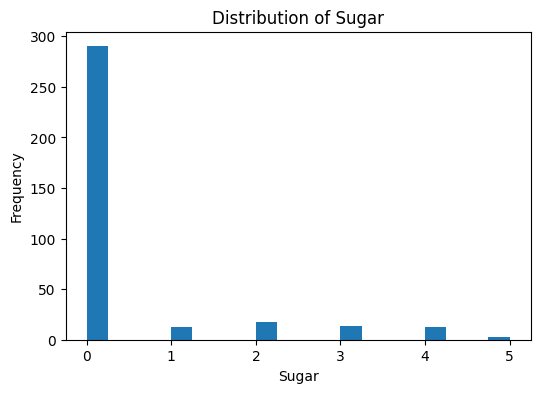

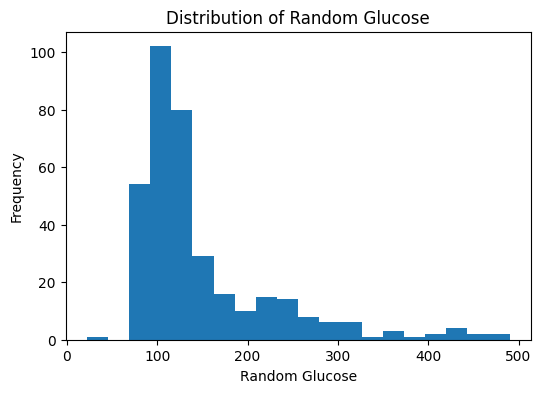

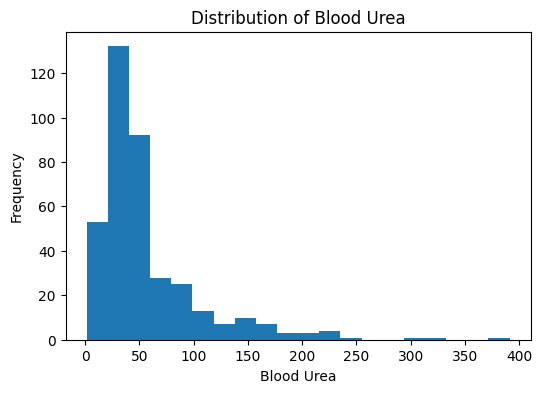

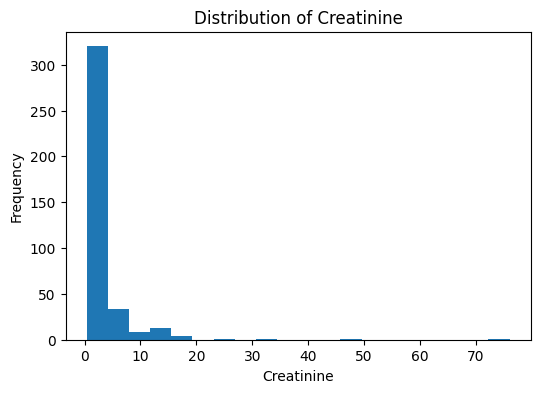

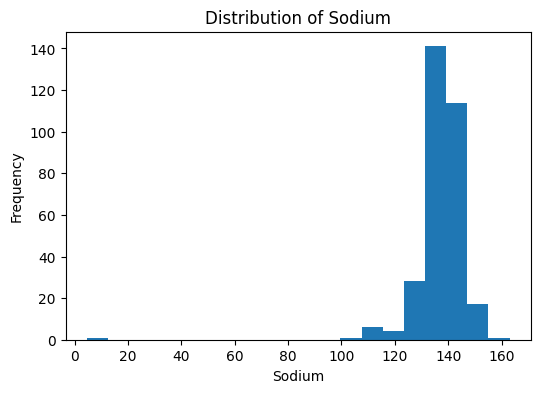

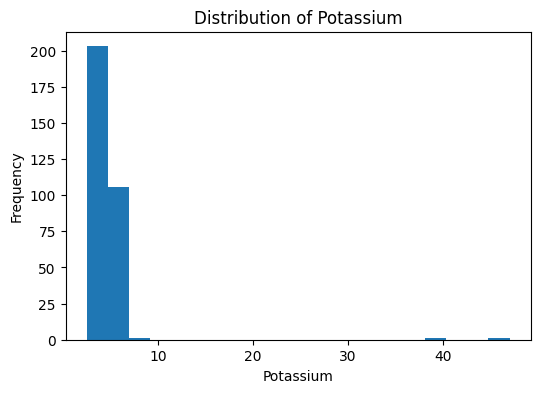

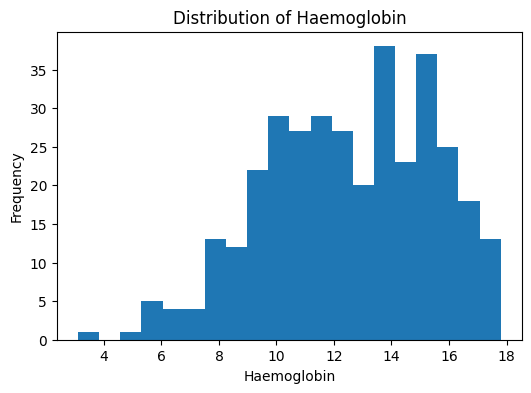

In [14]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [15]:
categorical_cols = df.select_dtypes(include="str").columns
categorical_cols

Index(['RBC', 'Pus Cell', 'PC Clumps', 'Bacteria', 'PCV', 'WBC Count',
       'RBC Count', 'Hypertension', 'Diabetes', 'Artery disease', 'Appetite',
       'Petal Edema', 'Anaemia', 'Classification'],
      dtype='str')

In [16]:
for col in categorical_cols:
    print(f"----{col}-----")
    print(df[col].value_counts(dropna=False))

----RBC-----
RBC
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64
----Pus Cell-----
Pus Cell
normal      259
abnormal     76
NaN          65
Name: count, dtype: int64
----PC Clumps-----
PC Clumps
notpresent    354
present        42
NaN             4
Name: count, dtype: int64
----Bacteria-----
Bacteria
notpresent    374
present        22
NaN             4
Name: count, dtype: int64
----PCV-----
PCV
NaN     70
52      21
41      21
44      19
48      19
40      16
43      14
45      13
42      13
32      12
36      12
33      12
28      12
50      12
37      11
34      11
35       9
29       9
30       9
46       9
31       8
39       7
24       7
26       6
38       5
47       4
49       4
53       4
51       4
54       4
27       3
22       3
25       3
23       2
19       2
16       1
\t?      1
14       1
18       1
17       1
15       1
21       1
20       1
\t43     1
9        1
Name: count, dtype: int64
----WBC Count-----
WBC Count
NaN     105
9800     11
6

In [17]:
#Target separation and Leakage Investigation
#ID-Target separation
target_binary = (
    df["Classification"].astype(str).str.strip().map({"ckd": 1, "notckd": 0})
)
print(df[["Id"]].assign(target=target_binary).corr())

df.groupby(target_binary)["Id"].agg(["min", "max", "median", "mean", "count"])

              Id    target
Id      1.000000 -0.838528
target -0.838528  1.000000


,min,max,median,mean,count
Classification,,,,,
0,250,399,324.5,324.5,150
1,0,249,124.5,124.5,250


In [18]:
categorical_cols = df.select_dtypes(include="object").columns.drop("Classification")

for col in categorical_cols:
    print(f"\n{'='*30}")
    print(col)
    print(pd.crosstab(
        df[col].str.strip(),
        target_binary,
        normalize="columns"
    ).round(3))


RBC


C:\Users\USER\AppData\Local\Temp\ipykernel_9856\4083859549.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.drop("Classification")


Classification    0      1
RBC                       
abnormal        0.0  0.439
normal          1.0  0.561

Pus Cell
Classification    0      1
Pus Cell                  
abnormal        0.0  0.392
normal          1.0  0.608

PC Clumps
Classification    0      1
PC Clumps                 
notpresent      1.0  0.832
present         0.0  0.168

Bacteria
Classification    0      1
Bacteria                  
notpresent      1.0  0.912
present         0.0  0.088

PCV
Classification      0      1
PCV                         
14              0.000  0.005
15              0.000  0.005
16              0.000  0.005
17              0.000  0.005
18              0.000  0.005
19              0.000  0.011
20              0.000  0.005
21              0.000  0.005
22              0.000  0.016
23              0.000  0.011
24              0.000  0.038
25              0.000  0.016
26              0.000  0.033
27              0.000  0.016
28              0.000  0.065
29              0.000  0.049
30        

In [19]:
#MIssingness by Target
missing_analysis = []

for col in df.columns:
    if df[col].isna().any():
        missing = df[col].isna()

        ckd_missing = missing[target_binary == 1].mean()
        notckd_missing = missing[target_binary == 0].mean()
        missing_analysis.append({
            "feature": col,
            "ckd_missing": ckd_missing * 100,
            "notckd_missing": notckd_missing * 100,
            "difference_%": (ckd_missing - notckd_missing) * 100
            
        })

missing_analysis = pd.DataFrame(missing_analysis)
missing_analysis.sort_values("difference_%", ascending=False)
missing_analysis
        

,feature,ckd_missing,notckd_missing,difference_%
0,Age,3.2,0.666667,2.533333
1,Blood Pressure,4.0,1.333333,2.666667
2,SG,16.8,3.333333,13.466667
3,Albumin,16.4,3.333333,13.066667
4,Sugar,17.6,3.333333,14.266667
5,RBC,57.2,6.000000,51.200000
6,Pus Cell,22.4,6.000000,16.400000
7,PC Clumps,0.0,2.666667,-2.666667
8,Bacteria,0.0,2.666667,-2.666667
9,Random Glucose,15.2,4.000000,11.200000


In [20]:
X = df.drop(columns=["Classification", "Id"])
y = df["Classification"].astype(str).str.strip()

y.value_counts()

Classification
ckd       250
notckd    150
Name: count, dtype: int64

In [21]:
X.dtypes

Age               float64
Blood Pressure    float64
SG                float64
Albumin           float64
Sugar             float64
RBC                   str
Pus Cell              str
PC Clumps             str
Bacteria              str
Random Glucose    float64
Blood Urea        float64
Creatinine        float64
Sodium            float64
Potassium         float64
Haemoglobin       float64
PCV                   str
WBC Count             str
RBC Count             str
Hypertension          str
Diabetes              str
Artery disease        str
Appetite              str
Petal Edema           str
Anaemia               str
dtype: object

In [22]:
for col in ["PCV", "WBC Count", "RBC Count"]:
    X[col] = pd.to_numeric(X[col], errors="coerce")
    print(f"\n{col}")
    print(X[col].unique()[: 20])



PCV
[44. 38. 31. 32. 35. 39. 36. 33. 29. 28. nan 16. 24. 37. 30. 34. 40. 45.
 27. 48.]

WBC Count
[ 7800.  6000.  7500.  6700.  7300.    nan  6900.  9600. 12100.  4500.
 12200. 11000.  3800. 11400.  5300.  9200.  6200.  8300.  8400. 10300.]

RBC Count
[5.2 nan 3.9 4.6 4.4 5.  4.  3.7 3.8 3.4 2.6 2.8 4.3 3.2 3.6 4.1 4.9 2.5
 4.2 4.5]


In [23]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
categorical_cols

C:\Users\USER\AppData\Local\Temp\ipykernel_9856\2312673782.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


['RBC',
 'Pus Cell',
 'PC Clumps',
 'Bacteria',
 'Hypertension',
 'Diabetes',
 'Artery disease',
 'Appetite',
 'Petal Edema',
 'Anaemia']

In [24]:
for col in categorical_cols:
    X[col] = X[col].astype(str).str.strip()
    print("\n")
    print(X[col].value_counts(dropna=False))



RBC
normal      201
NaN         152
abnormal     47
Name: count, dtype: int64


Pus Cell
normal      259
abnormal     76
NaN          65
Name: count, dtype: int64


PC Clumps
notpresent    354
present        42
NaN             4
Name: count, dtype: int64


Bacteria
notpresent    374
present        22
NaN             4
Name: count, dtype: int64


Hypertension
no     251
yes    147
NaN      2
Name: count, dtype: int64


Diabetes
no     261
yes    137
NaN      2
Name: count, dtype: int64


Artery disease
no     364
yes     34
NaN      2
Name: count, dtype: int64


Appetite
good    317
poor     82
NaN       1
Name: count, dtype: int64


Petal Edema
no     323
yes     76
NaN      1
Name: count, dtype: int64


Anaemia
no     339
yes     60
NaN      1
Name: count, dtype: int64


In [25]:
numeric_cols = X.select_dtypes(include="number").columns.tolist()
numeric_cols

['Age',
 'Blood Pressure',
 'SG',
 'Albumin',
 'Sugar',
 'Random Glucose',
 'Blood Urea',
 'Creatinine',
 'Sodium',
 'Potassium',
 'Haemoglobin',
 'PCV',
 'WBC Count',
 'RBC Count']

In [26]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", StandardScaler())
])


categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [27]:
y.value_counts(normalize=True, dropna=False)
print(y.shape)
print(X.shape)


(400,)
(400, 24)


In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(320, 24)
(80, 24)
(320,)
(80,)


In [29]:
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000))
])

lr_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [30]:
y_pred = lr_pipeline.predict(X_test)
y_prob = lr_pipeline.predict_proba(X_test)[:, 1]


In [31]:
from sklearn.metrics import (classification_report, accuracy_score, roc_auc_score, confusion_matrix)
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy Score: 0.9625
              precision    recall  f1-score   support

         ckd       0.96      0.98      0.97        50
      notckd       0.97      0.93      0.95        30

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80

ROC-AUC: 0.9986666666666667
Confusion Matrix:
[[49  1]
 [ 2 28]]


In [32]:
print(X.columns.tolist())
print(y.value_counts())

['Age', 'Blood Pressure', 'SG', 'Albumin', 'Sugar', 'RBC', 'Pus Cell', 'PC Clumps', 'Bacteria', 'Random Glucose', 'Blood Urea', 'Creatinine', 'Sodium', 'Potassium', 'Haemoglobin', 'PCV', 'WBC Count', 'RBC Count', 'Hypertension', 'Diabetes', 'Artery disease', 'Appetite', 'Petal Edema', 'Anaemia']
Classification
ckd       250
notckd    150
Name: count, dtype: int64


In [33]:
X.groupby(y)[numeric_cols].median().T

Classification,ckd,notckd
Age,59.000,46.00
Blood Pressure,80.000,70.00
SG,1.015,1.02
Albumin,2.000,0.00
Sugar,0.000,0.00
Random Glucose,143.500,107.50
Blood Urea,53.000,33.00
Creatinine,2.250,0.90
Sodium,136.000,141.00
Potassium,4.300,4.50


In [34]:
numeric_transformer_no_indicator=Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", StandardScaler())
])

preprocessor_no_indicator = ColumnTransformer(transformers=[
    ("num", numeric_transformer_no_indicator, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

lr_pipeline_no_indicator = Pipeline(steps=[
    ("preprocessor", preprocessor_no_indicator),
    ("model", LogisticRegression(max_iter=2000))
])


lr_pipeline_no_indicator.fit(X_train, y_train)
y_pred_no = lr_pipeline.predict(X_test)
y_prob_no = lr_pipeline.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred_no)}")
print(classification_report(y_test, y_pred_no))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_no))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_no))

Accuracy Score: 0.9625
              precision    recall  f1-score   support

         ckd       0.96      0.98      0.97        50
      notckd       0.97      0.93      0.95        30

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80

ROC-AUC: 0.9986666666666667
Confusion Matrix:
[[49  1]
 [ 2 28]]


In [35]:
print(lr_pipeline.classes_)

['ckd' 'notckd']


In [36]:
y_pred_train = lr_pipeline.predict(X_train)
y_prob_train = lr_pipeline.predict_proba(X_train)[:, 0]

print(f"Train Accuracy: {accuracy_score(y_train, y_pred_train)}")
print(f"Train classif: {classification_report(y_train, y_pred_train)}")

train_roc_auc = roc_auc_score(
    (y_train == "ckd").astype(int),
    y_prob_train
)
print(train_roc_auc)

Train Accuracy: 1.0
Train classif:               precision    recall  f1-score   support

         ckd       1.00      1.00      1.00       200
      notckd       1.00      1.00      1.00       120

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320

1.0


In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    lr_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "roc_auc": "roc_auc",
        "f1": "f1_weighted"
    },
    return_train_score=True,
    n_jobs=-1
)


In [55]:
cv_results

{'fit_time': array([0.10710096, 0.09979105, 0.11160135, 0.08193994, 0.08030009]),
 'score_time': array([0.09557724, 0.06651497, 0.09344196, 0.07061815, 0.0764761 ]),
 'test_accuracy': array([1.      , 0.96875 , 0.984375, 1.      , 0.96875 ]),
 'train_accuracy': array([1., 1., 1., 1., 1.]),
 'test_roc_auc': array([1.        , 1.        , 1.        , 1.        , 0.99166667]),
 'train_roc_auc': array([1., 1., 1., 1., 1.]),
 'test_f1': array([1.        , 0.96897436, 0.98443555, 1.        , 0.96845175]),
 'train_f1': array([1., 1., 1., 1., 1.])}

In [39]:
y_binary = (y == "ckd").astype(int)

correlation = X[numeric_cols].corrwith(y_binary).sort_values(
    key=abs,
    ascending=False
)

correlation

Haemoglobin      -0.768919
PCV              -0.741427
SG               -0.732163
RBC Count        -0.699089
Albumin           0.627090
Random Glucose    0.419672
Blood Urea        0.380605
Sodium           -0.375674
Sugar             0.344070
Creatinine        0.299969
Blood Pressure    0.294077
WBC Count         0.231919
Age               0.227268
Potassium         0.084541
dtype: float64

In [40]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    "model__C": [0.001, 0.01, 0.1, 1, 10, 100]
}

grid_search = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1  
)

grid_search.fit(X_train, y_train)

print(f"Best parametes: ", grid_search.best_params_)
print(f"Best CV ROC_AUC: ", grid_search.best_score_)


Best parametes:  {'model__C': 10}
Best CV ROC_AUC:  1.0


In [41]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 0]

print(accuracy_score(y_test, y_pred_tuned))

test_roc = roc_auc_score(
    (y_test == "ckd").astype(int),
    y_prob_tuned
)
print(test_roc)
print(f"\nClassification Report: {classification_report(y_test, y_pred_tuned)}")

0.9625
0.9986666666666667

Classification Report:               precision    recall  f1-score   support

         ckd       0.96      0.98      0.97        50
      notckd       0.97      0.93      0.95        30

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



In [42]:
from sklearn.calibration import calibration_curve
final_model = grid_search.best_estimator_

y_prob_ckd = final_model.predict_proba(X_test)[:, 0]
y_binary = (y_test == "ckd").astype(int)

prob_true, prob_pred = calibration_curve(
    y_binary,
    y_prob_ckd,
    n_bins=5,
    strategy="uniform"
)


print("Mean predicted probability:", prob_pred)
print("Observed CKD frequency:", prob_true)


Mean predicted probability: [0.01119188 0.58396477 0.66571536 0.99783003]
Observed CKD frequency: [0.03448276 0.         0.         1.        ]


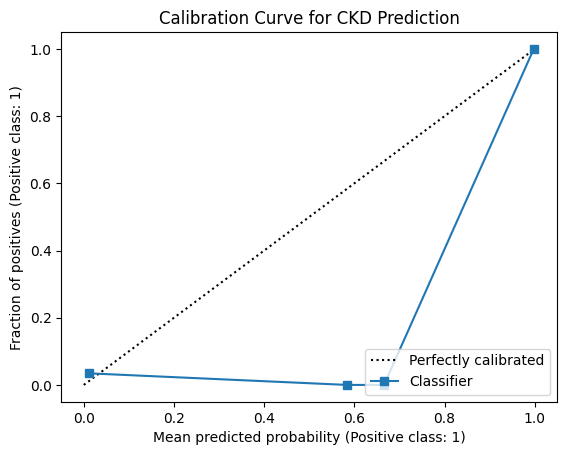

In [43]:
import matplotlib.pyplot as plt
from sklearn.calibration import CalibrationDisplay

CalibrationDisplay.from_predictions(
    y_binary,
    y_prob_ckd,
    n_bins=5,
    strategy="uniform"
)

plt.title("Calibration Curve for CKD Prediction")
plt.show()

In [45]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42
)

perm_importance

{'importances_mean': array([ 2.22044605e-17,  5.33333333e-04,  1.26000000e-02,  2.93333333e-03,
         2.22044605e-17,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  6.20000000e-03,
         2.00000000e-04,  4.00000000e-04,  9.20000000e-03, -3.33333333e-04,
         0.00000000e+00,  2.66666667e-03,  4.00000000e-04,  8.00000000e-04,
         0.00000000e+00,  3.33333333e-04,  3.33333333e-04,  0.00000000e+00]),
 'importances_std': array([0.00066667, 0.0009798 , 0.00562099, 0.00310125, 0.00059628,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.01034107, 0.00030551, 0.0003266 , 0.00468378,
        0.00095452, 0.        , 0.00221108, 0.00044222, 0.00083267,
        0.        , 0.00033333, 0.00085635, 0.        ]),
 'importances': array([[ 0.00000000e+00, -1.33333333e-03,  6.66666667e-04,
          0.00000000e+00,  0.00000000e+00, -6.66666667e-04,
          0.00000000e+00,  1.33333333e

In [48]:
feature_names = X_test.columns

importance_df = pd.DataFrame({
    "feature_name": feature_names,
    "importance_std": perm_importance.importances_std,
    "importance_mean": perm_importance.importances_mean
    
}).sort_values(
    "importance_mean",
    ascending=False
)

importance_df

,feature_name,importance_std,importance_mean
2,SG,0.005621,1.260000e-02
14,Haemoglobin,0.004684,9.200000e-03
11,Creatinine,0.010341,6.200000e-03
3,Albumin,0.003101,2.933333e-03
17,RBC Count,0.002211,2.666667e-03
19,Diabetes,0.000833,8.000000e-04
1,Blood Pressure,0.000980,5.333333e-04
13,Potassium,0.000327,4.000000e-04
18,Hypertension,0.000442,4.000000e-04
22,Petal Edema,0.000856,3.333333e-04


In [60]:
print("Fold ROC-AUC scores:", cv_results["test_roc_auc"])
print("Mean ROC-AUC:", cv_results["test_roc_auc"].mean())
print("Std ROC-AUC:", cv_results["test_roc_auc"].std())

Fold ROC-AUC scores: [1.         1.         1.         1.         0.99166667]
Mean ROC-AUC: 0.9983333333333334
Std ROC-AUC: 0.0033333333333333214


In [79]:

ablation_results = []
for feature in X_train.columns:
    reduced_numeric = [col for col in numeric_cols if col != feature]
    reduced_categorical = [col for col in categorical_cols if col != feature]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder())
    ])

    preprocessor = ColumnTransformer(transformers=[
        ("num", numeric_transformer, reduced_numeric),
        ("cat", categorical_transformer, reduced_categorical)
    ])

    ablation_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(C=10, max_iter=1000))
    ])
    
    
    X_reduced = X_train.drop(columns=[feature])

    cross_val = cross_validate(
        ablation_model,
        X_reduced,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

    ablation_results.append({
        "feature": feature,
        "mean_roc_auc": cross_val["test_score"].mean(),
        "std_roc_auc": cross_val["test_score"].std()
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("mean_roc_auc", ascending=False)

ablation_df

,feature,mean_roc_auc,std_roc_auc
0,Age,1.000000,0.000000
1,Blood Pressure,1.000000,0.000000
3,Albumin,1.000000,0.000000
5,RBC,1.000000,0.000000
7,PC Clumps,1.000000,0.000000
6,Pus Cell,1.000000,0.000000
9,Random Glucose,1.000000,0.000000
8,Bacteria,1.000000,0.000000
20,Artery disease,1.000000,0.000000
17,RBC Count,1.000000,0.000000


In [67]:
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [70]:
print(numeric_cols
print(categorical_cols)


AttributeError: 'list' object has no attribute 'dtype'

In [81]:
final_model.get_params()["model__C"]

10

In [84]:
y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]

# Final metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))


print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.9625
ROC-AUC: 0.9986666666666667

Classification Report:
              precision    recall  f1-score   support

         ckd       0.96      0.98      0.97        50
      notckd       0.97      0.93      0.95        30

    accuracy                           0.96        80
   macro avg       0.96      0.96      0.96        80
weighted avg       0.96      0.96      0.96        80



In [85]:
final_model.fit(X, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [87]:
import joblib
joblib.dump(final_model, "ckd_model.joblib")

['ckd_model.joblib']

In [88]:
import os
os.path.exists("ckd_model.joblib")

True